In [1]:
from typing import Callable, List, Optional, Tuple, Union

import scanpy as sc
import scvelo as scv
import anndata as ad
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

import pandas as pd
import numpy as np
import pickle
from sklearn import preprocessing
import json
import torch
from torch import nn
from torch.autograd.functional import jacobian
import os
from torchdiffeq import odeint
from sklearn.decomposition import PCA
from scipy.stats import pearsonr, linregress
from sklearn.metrics.pairwise import cosine_similarity
from scipy.io import loadmat
from scipy.interpolate import interp1d
from scipy.optimize import OptimizeResult, minimize
import dynamo as dyn
dyn.dynamo_logger.main_silence()
sc.settings.set_figure_params(dpi=80, dpi_save=300, fontsize=14)
plt.rcParams['axes.grid'] = False
plt.rcParams['svg.fonttype']='none'
plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings('ignore')

In [2]:
def arrowed_spines(ax, columns, background="white"):
    """
    画左下角箭头的函数，引自dynamo
    """
    if type(columns) == str:
        columns = [columns.upper() + " 1", columns.upper() + " 2"]
    import matplotlib.pyplot as plt

    fig = plt.gcf()

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # removing the default axis on all sides:
    despline_all(ax)

    # removing the axis ticks
    deaxis_all(ax)

    # get width and height of axes object to compute
    # matching arrowhead length and width
    dps = fig.dpi_scale_trans.inverted()
    bbox = ax.get_window_extent().transformed(dps)
    width, height = bbox.width, bbox.height

    # manual arrowhead width and length (x-axis)
    hw = 1.0 / 20.0 * (ymax - ymin)
    hl = 1.0 / 20.0 * (xmax - xmin)
    lw = 1.0  # axis line width
    ohg = 0.2  # arrow overhang

    # compute matching arrowhead length and width (y-axis)
    yhw = hw / (ymax - ymin) * (xmax - xmin) * height / width
    yhl = hl / (xmax - xmin) * (ymax - ymin) * width / height

    # draw x and y axis
    fc, ec = ("w", "w") if background in ["black", "#ffffff"] else ("k", "k")
    ax.arrow(
        xmin,
        ymin,
        hl * 5 / 2,
        0,
        fc=fc,
        ec=ec,
        lw=lw,
        head_width=hw / 2,
        head_length=hl / 2,
        overhang=ohg / 2,
        length_includes_head=True,
        clip_on=False,
    )
    ax.arrow(
        xmin,
        ymin,
        0,
        hw * 5 / 2,
        fc=fc,
        ec=ec,
        lw=lw,
        head_width=yhw / 2,
        head_length=yhl / 2,
        overhang=ohg / 2,
        length_includes_head=True,
        clip_on=False,
    )

    ax.text(
        xmin + hl * 2.5 / 2,
        ymin - 1.5 * hw / 2,
        columns[0],
        ha="center",
        va="center",
        rotation=0,
        # size=hl * 5 / (2 * len(str(columns[0]))) * 20,
        # size=matplotlib.rcParams['axes.titlesize'],
        size=np.clip((hl + yhw) * 8 / 2, 6, 18),
    )
    ax.text(
        xmin - 1.5 * yhw / 2,
        ymin + hw * 2.5 / 2,
        columns[1],
        ha="center",
        va="center",
        rotation=90,
        # size=hw * 5 / (2 * len(str(columns[1]))) * 20,
        # size=matplotlib.rcParams['axes.titlesize'],
        size=np.clip((hl + yhw) * 8 / 2, 6, 18),
    )

    return ax

def despline_all(ax=None, sides=None):
    # removing the default axis on all sides:
    import matplotlib.pyplot as plt

    ax = plt.gca() if ax is None else ax

    if sides is None:
        sides = ["bottom", "right", "top", "left"]
    for side in sides:
        ax.spines[side].set_visible(False)


def deaxis_all(ax=None):
    # removing the axis ticks
    import matplotlib.pyplot as plt

    ax = plt.gca() if ax is None else ax

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

In [3]:
class Encoder(nn.Module):
    def __init__(
        self,
        n_int: int,
        n_latent: int = 20,
        n_hidden: int = 128,
        batch_norm: bool = False,
    ):
        super().__init__()

        self.fc1 = nn.Sequential()
        self.fc1.add_module('L1', nn.Linear(n_int, n_hidden))
        if batch_norm:
            self.fc1.add_module('N1', nn.BatchNorm1d(n_hidden))
        self.fc1.add_module('A1', nn.LeakyReLU())
        self.fc2_mean = nn.Linear(n_hidden, n_latent)
        self.fc2_logvar = nn.Linear(n_hidden, n_latent)

    def forward(self, x: torch.Tensor):
        x = self.fc1(x)
        mean = self.fc2_mean(x)
        logvar = self.fc2_logvar(x)
        return mean, logvar

class Decoder(nn.Module):
    def __init__(
        self,
        n_int: int,
        n_latent: int = 20,
        n_hidden: int = 128,
        batch_norm: bool = False,
    ):
        super().__init__()
        self.fc1 = nn.Sequential()
        self.fc1.add_module('L1', nn.Linear(n_latent, n_hidden))
        if batch_norm:
            self.fc1.add_module('N1', nn.BatchNorm1d(n_hidden))
        # self.fc1.add_module('A1', nn.LeakyReLU())
        self.fc2 = nn.Linear(n_hidden, n_int)

    def forward(self, z: torch.Tensor):
        z = self.fc1(z)
        recon_x = self.fc2(z)
        return recon_x

class LatentODE(nn.Module):
    def __init__(
        self,
        n_latent: int = 20,
        n_hidden: int = 32,
    ):
        super(LatentODE, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(in_features=n_latent, out_features=n_hidden, bias=True),
            nn.ELU())

        self.layer2 = nn.Sequential(
            nn.Linear(in_features=n_hidden, out_features=n_hidden, bias=True),
            nn.BatchNorm1d(n_hidden),
            nn.ELU())

        self.layer4 = nn.Sequential(
            nn.Linear(in_features=n_hidden, out_features=n_latent, bias=True)
            )

    def forward(self, t, x):
        fc1 = self.layer1(x)
        fc2 = self.layer2(fc1)
        output = self.layer4(fc2)
        return output

In [4]:
## 加载训练好的模型
encoder = Encoder(n_int=1066)
decoder = Decoder(n_int=1066)
dynamics_learner = LatentODE()
dynamics_learner.load_state_dict(torch.load('Parameters_dynamics.pickle', map_location=torch.device('cpu')))
encoder.load_state_dict(torch.load('Parameters_encoder.pickle', map_location=torch.device('cpu')))
decoder.load_state_dict(torch.load('Parameters_decoder.pickle', map_location=torch.device('cpu')))
dynamics_learner.eval()
encoder.eval()
decoder.eval()

Decoder(
  (fc1): Sequential(
    (L1): Linear(in_features=20, out_features=128, bias=True)
  )
  (fc2): Linear(in_features=128, out_features=1066, bias=True)
)

In [5]:
adata = sc.read("adata_U2OS_DeepCycle.h5ad")
adata.var.index = adata.var['name']

In [6]:
bdata = sc.read("adata_U2OS_DeepCycle.h5ad")
dyn.pp.recipe_monocle(bdata)
adata.obs['cell_cycle_phase'] = bdata.obs['cell_cycle_phase']
# 将theta的初始时刻平移至G1期初始
adata.obs['theta'] = adata.obs['theta'] - 0.27
adata.obs['theta'] = adata.obs['theta'].apply(lambda x: x + 1 if x < 0 else x)
adata

|-----> apply Monocole recipe to adata...
|-----> convert ensemble name to official gene name
|-----? Your adata object uses non-official gene names as gene index. 
Dynamo is converting those names to official gene names.


49 input query terms found no hit:	['ENSG00000112096', 'ENSG00000130489', 'ENSG00000130723', 'ENSG00000168078', 'ENSG00000170152', 'ENS


|-----> ensure all cell and variable names unique.
|-----> ensure all data in different layers in csr sparse matrix format.
|-----> ensure all labeling data properly collapased
|-----> filtering cells...
|-----> 1040 cells passed basic filters.
|-----> filtering gene...
|-----> 10889 genes passed basic filters.
|-----> calculating size factor...
|-----> selecting genes in layer: X, sort method: SVR...
|-----> applying PCA ...
|-----> cell cycle scoring...
|-----> computing cell phase...
|-----> [Cell Phase Estimation] completed [26.0987s]
|-----> [Cell Cycle Scores Estimation] completed [0.0760s]
|-----> [recipe_monocle preprocess] completed [17.7960s]


AnnData object with n_obs × n_vars = 1040 × 13450
    obs: 'Well_Plate', 'plate', 'phase', 'MeanGreen530', 'MeanRed585', 'fucci_time', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_genes', 'n_counts', 'original_louvain_wp', 'original_louvain', 'Green530', 'Red585', 'louvain', 'theta', 'cell_cycle_theta', 'cell_cycle_phase'
    var: 'name', 'biotype', 'description', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'GeneName', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'louvain', 'neighbors', 'pca', 'phase_colors', 'plate_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'spanning', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [7]:
## 得到伪时间
percentiles = np.percentile(adata.obs['theta'], np.linspace(0, 100, 100))
indices = np.digitize(adata.obs['theta'], percentiles)
pseudotime = indices * 0.01
adata.obs['pseudotime'] = pseudotime

In [8]:
th=adata.obs['pseudotime']
minima = min(th)
maxima = max(th)
norm = matplotlib.colors.Normalize(vmin=minima, vmax=maxima)
mapper = cm.ScalarMappable(norm=norm, cmap=cm.viridis)

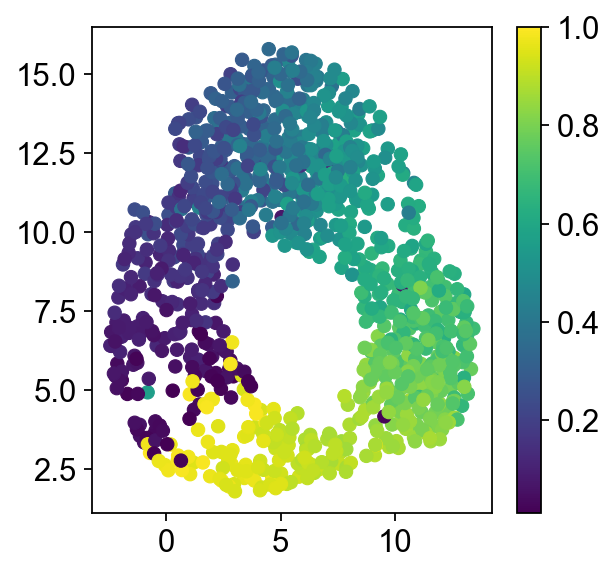

In [9]:
plt.scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],c=th,cmap=cm.viridis)
plt.colorbar(mapper, ax=plt.gca())
# plt.savefig('latent.png', dpi=300)

In [10]:
list_of_genes_file = "genes_1066.json"
expression_threshold = 5
with open(list_of_genes_file,'r') as fp:
    cell_cycle_genes = json.load(fp)

In [11]:
## 数据准备
def generate_input(list_of_genes, adata):
    gene_list = list(adata.var.index)
    n = gene_list.index(list_of_genes[0])
    df_all = pd.DataFrame({ 'spliced':adata.layers['Ms'][:,n], 'unspliced':adata.layers['Mu'][:,n] })

    for gene in list_of_genes[1:]:
        try:
            n = gene_list.index(gene)
            df = pd.DataFrame({ 'spliced':adata.layers['Ms'][:,n], 'unspliced':adata.layers['Mu'][:,n] })
            if (df.mean()<expression_threshold).all():
                list_of_genes.remove(gene)
                continue
        except ValueError:
            list_of_genes.remove(gene)
            continue
        df_all = pd.concat([df_all, df], axis=1)

    normalized_df=(df_all-df_all.mean())/df_all.std()
    np_data = normalized_df.to_numpy()
    nan_columns = list(np.where(np.any(~np.isfinite(np_data),axis=0))[0])
    nan_indexes = list([ n//2 for n in nan_columns])
    even_columns = list([ 2*n for n in nan_indexes ])
    odd_columns = list([ 2*n+1 for n in nan_indexes ])
    for idx in sorted(nan_indexes, reverse=True):
        del list_of_genes[idx]
    columns_to_drop = sorted(even_columns + odd_columns)
    normalized_df.columns = list(range(normalized_df.shape[1]))
    df_all.columns = list(range(df_all.shape[1]))
    df_all = df_all.drop(df_all.columns[columns_to_drop], axis=1)
    normalized_df = normalized_df.drop(normalized_df.columns[columns_to_drop], axis=1)
    #print("Left genes: ",len(list_of_genes), normalized_df.shape)
    
    return list_of_genes, normalized_df.to_numpy() #cells x (2 genes)

In [12]:
## 过滤数据
genes, np_data = generate_input(cell_cycle_genes, adata)
print("[Genes]:", genes)
print("[N. OF USED GENES]",len(genes))
n_genes = len(genes)
n_cells = np_data.shape[0]
n_columns = np_data.shape[1]
if n_columns != 2*n_genes:
    print("[ERROR]: incoherent number of genes and columns")

print( "[Total number of cells]:", n_cells)

[Genes]: ['AAAS', 'AATF', 'ABL1', 'ABRAXAS2', 'ACTB', 'ACTR1A', 'ACTR2', 'ACTR3', 'ACTR8', 'ACVR1', 'ADAM10', 'ADAMTS1', 'AHCTF1', 'AKAP8', 'AKAP9', 'AKT1', 'AKT2', 'ALKBH4', 'ALMS1', 'ANAPC1', 'ANAPC11', 'ANAPC13', 'ANAPC15', 'ANAPC16', 'ANAPC4', 'ANAPC5', 'ANAPC7', 'ANGEL2', 'ANKLE2', 'ANKRD17', 'ANLN', 'ANXA1', 'ANXA11', 'APBB1', 'APBB2', 'APC', 'APEX1', 'APEX2', 'APP', 'APPL1', 'APPL2', 'ARAP1', 'ARF1', 'ARF6', 'ARL3', 'ARL8B', 'ARNTL', 'ARPP19', 'ASPM', 'ATAD5', 'ATF2', 'ATP2B4', 'ATR', 'ATRX', 'AURKA', 'AURKAIP1', 'AURKB', 'AVPI1', 'AZI2', 'BABAM2', 'BACH1', 'BAG6', 'BANP', 'BAP1', 'BARD1', 'BAX', 'BBS4', 'BCAT1', 'BCCIP', 'BCL2', 'BCL2L1', 'BECN1', 'BEX2', 'BID', 'BIN1', 'BIN3', 'BIRC2', 'BIRC5', 'BIRC6', 'BLM', 'BMP4', 'BOD1', 'BOP1', 'BORA', 'BRCA1', 'BRCA2', 'BRD4', 'BRD7', 'BRIP1', 'BTG1', 'BTG2', 'BTG3', 'BTRC', 'BUB1', 'BUB1B', 'BUB3', 'C2CD3', 'C6orf89', 'CAB39', 'CACUL1', 'CALM1', 'CALM3', 'CALR', 'CAMK2N1', 'CASP2', 'CASP3', 'CAV2', 'CBX3', 'CBX5', 'CCAR1', 'CCAR2', 'CC

In [13]:
## 归一化细胞数据
np_data = np_data[:, ::2]

for i in range(np_data.shape[1]):
    gene_data = np_data[:, i]
    gene_data -= gene_data.min()
    gene_data /= gene_data.max()
    np_data[:, i] = gene_data
np_data.shape

(1040, 1066)

In [14]:
## 计算重构及潜表示
raw = torch.as_tensor(np_data, dtype=torch.float32)
latent, _ = encoder(raw)
mean = latent.mean(0).detach()
std = latent.std(0).detach()
latent_std = torch.exp(0.5 * encoder(raw)[1])
reconstruct = decoder(latent)

raw = raw.detach().numpy()
reconstruct = reconstruct.detach().numpy()
latent = latent.detach().numpy()
latent_std = latent_std.detach().numpy()

In [15]:
latent_std.mean(0)

array([0.01423306, 0.99998826, 0.9971218 , 0.9976258 , 0.9982652 ,
       0.99763596, 0.99695396, 0.99971724, 0.01039779, 0.9990738 ,
       0.01292057, 0.9985256 , 0.99838185, 0.00901267, 0.9987287 ,
       0.00797676, 0.99852246, 0.9972889 , 0.00807239, 0.01422244],
      dtype=float32)

In [16]:
## 对隐空间坐标标准化
latent_z = (latent - latent.mean(0))/latent.std(0)

In [17]:
## 计算velocity
velocity = np.zeros_like(latent)
for i in range(velocity.shape[0]):
    x0 = latent_z[i, :].reshape(1,-1)
    x1 = torch.as_tensor(x0, dtype=torch.float32)
    f = dynamics_learner(0, x1)
    v = f.detach().numpy()
    velocity[i, :] = np.squeeze(v)

In [18]:
## 对标准化latent坐标PCA降维
pca = PCA(n_components=2)
pca.fit(latent_z)
V = pca.components_.T
ratio = pca.explained_variance_ratio_
latent_z_pca = (latent_z - np.mean(latent_z, axis=0)) @ V

# 得到速率投影
v_pca = velocity @ V
v_norm = (v_pca.T/np.linalg.norm(v_pca, axis=1)).T

In [19]:
cwd = os.getcwd()
print("[Current working directory]:",cwd)
AE_dir = cwd+'/AE_fit/'
if not os.path.exists(AE_dir):
    os.makedirs(AE_dir)

[Current working directory]: D:\ROG\desktop\振荡动力学推断结果整理\code\U2OScellcycle数据


In [20]:
# for gene in genes:
#     index = genes.index(gene)
#     fig, ax = plt.subplots()
#     sns.scatterplot(adata.obs['theta'],raw[:, index],alpha=0.1,ax=ax)
#     ax.set_title(genes[index])
#     ax.set_ylabel('raw')
#     plt.ylim(-0.1, 1.1)
#     plt.xlim(-0.1, 1.1)
#     plt.savefig(AE_dir+gene+'_raw.png')
#     plt.clf()
#     fig, ax = plt.subplots()
#     sns.scatterplot(adata.obs['theta'],reconstruct[:, index],alpha=0.1,ax=ax)
#     ax.set_title(genes[index])
#     ax.set_ylabel('reconstruct')
#     plt.ylim(-0.1, 1.1)
#     plt.xlim(-0.1, 1.1)
#     plt.savefig(AE_dir+gene+'_reconstruct.png')
#     plt.clf()

In [21]:
for t in range(20):
    fig, ax = plt.subplots()
    sns.scatterplot(x=adata.obs['theta'],y=latent[:, t],alpha=0.1,ax=ax)
    ax.set_title(t)
    ax.set_ylabel('latent_rep')
    plt.xlim(-0.1, 1.1)
    plt.savefig(AE_dir+str(t)+'_latent_rep.png')
    plt.clf()
    fig, ax = plt.subplots()
    sns.scatterplot(x=adata.obs['theta'],y=latent_std[:, t],alpha=0.1,ax=ax)
    ax.set_title(t)
    ax.set_ylabel('latent_std')
    plt.xlim(-0.1, 1.1)
    plt.savefig(AE_dir+str(t)+'_latent_std.png')
    plt.clf()

<Figure size 320x320 with 0 Axes>

<Figure size 320x320 with 0 Axes>

<Figure size 320x320 with 0 Axes>

<Figure size 320x320 with 0 Axes>

<Figure size 320x320 with 0 Axes>

...

<Figure size 320x320 with 0 Axes>

<Figure size 320x320 with 0 Axes>

<Figure size 320x320 with 0 Axes>

<Figure size 320x320 with 0 Axes>

<Figure size 320x320 with 0 Axes>

In [22]:
# set initial points
# kk = 0.5
# x0 = np.ones((1, 2132))*kk
x0 = np_data[0,:].reshape(-1,1066)

# the length of sequence we predict
NK = 10000

t = torch.arange(0, 0.005 * NK, 0.005)

xx = np.zeros((1066, NK))

x1 = torch.as_tensor(x0, dtype=torch.float32)
encoded, _ = encoder(x1)
encoded = (encoded - mean)/std

latent_t = odeint(dynamics_learner, encoded, t, method='rk4')
latent_t = latent_t.permute(1, 2, 0).squeeze() # ode的解

for i in range(NK):
    encoded = latent_t[:, i]
    encoded = encoded * std + mean
    x0 = decoder(encoded)
    x0 = x0.detach().numpy()
    xx[:, i] = x0
    
latent_t = latent_t.detach().numpy()

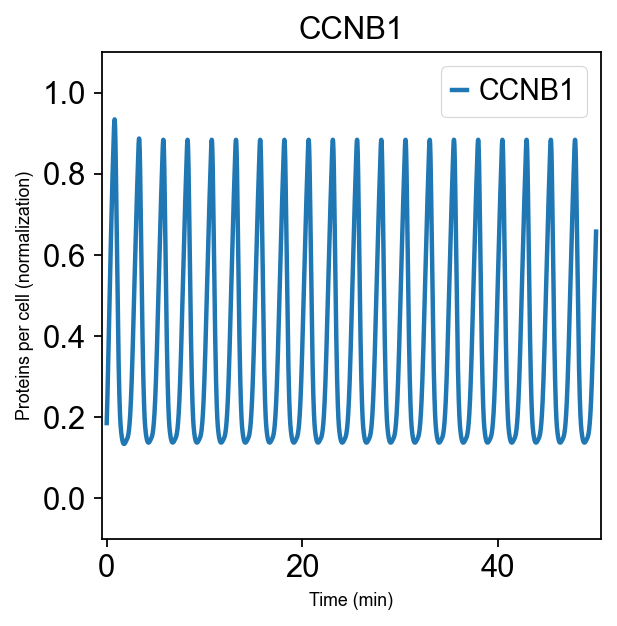

In [23]:
gene='CCNB1'
index = genes.index(gene)
plt.plot(t, xx[index,:], label=gene, linewidth=2.0)
plt.ylim(-0.1, 1.1)
plt.xlim(-10 * 0.05, 1010 * 0.05)
plt.xlabel("Time (min)", fontsize=8, family='Arial')
plt.ylabel("Proteins per cell (normalization)", fontsize=8, family='Arial')
plt.title(gene)
plt.legend()

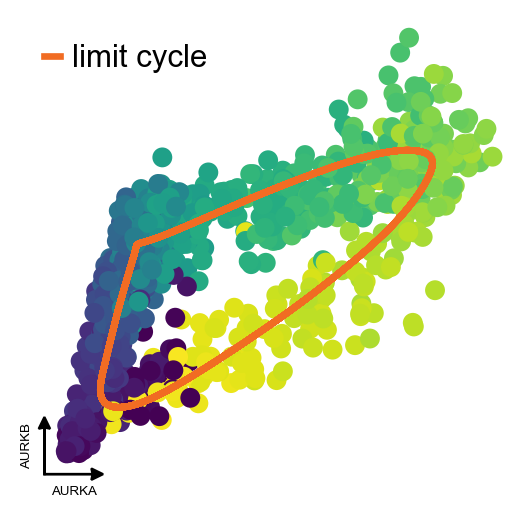

In [24]:
gene1 = 'AURKA'
gene2 = 'AURKB'
index1 = genes.index(gene1)
index2 = genes.index(gene2)
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(xx[index1, 5000:], xx[index2, 5000:], linewidth=3.0, color='#f16c23', label='limit cycle')
ax.scatter(np_data[:, index1], np_data[:, index2], c=th, cmap=cm.viridis, s=80, alpha=1, edgecolors='none')
arrowed_spines(ax, columns=[gene1,gene2])
ax.legend(loc='best', fontsize=14, frameon=False)
plt.savefig(f"figures/{gene1}_{gene2}_cycle.svg", bbox_inches='tight', transparent=True)
plt.show()

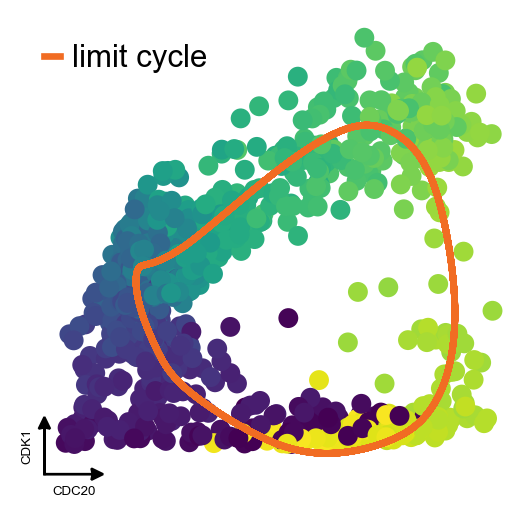

In [25]:
gene1 = 'CDC20'
gene2 = 'CDK1'
index1 = genes.index(gene1)
index2 = genes.index(gene2)
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(xx[index1, 5000:], xx[index2, 5000:], linewidth=3.0, color='#f16c23', label='limit cycle')
ax.scatter(np_data[:, index1], np_data[:, index2], c=th, cmap=cm.viridis, s=80, alpha=1, edgecolors='none')
arrowed_spines(ax, columns=[gene1,gene2])
ax.legend(loc='best', fontsize=14, frameon=False)
plt.savefig(f"figures/{gene1}_{gene2}_cycle.svg", bbox_inches='tight', transparent=True)
plt.show()

Text(0.5, 1.0, 'CDC20_CDK1')

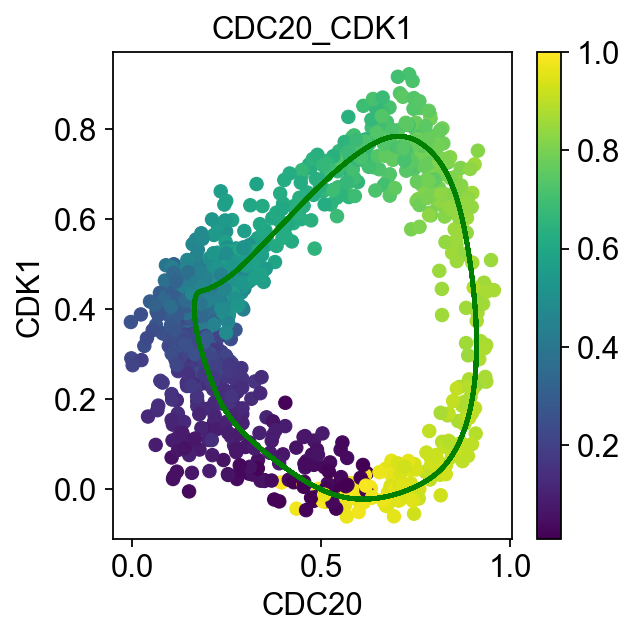

In [26]:
gene1 = 'CDC20'
gene2 = 'CDK1'
index1 = genes.index(gene1)
index2 = genes.index(gene2)
plt.plot(xx[index1, 5000:], xx[index2, 5000:], linewidth=2.0, color='green')
plt.scatter(reconstruct[:, index1], reconstruct[:, index2],c=th,cmap=cm.viridis)
plt.colorbar(mapper, ax=plt.gca())
plt.xlabel(gene1)
plt.ylabel(gene2)
plt.title(gene1+'_'+gene2)
# plt.savefig(gene1+'_'+gene2+'.png', dpi=300)

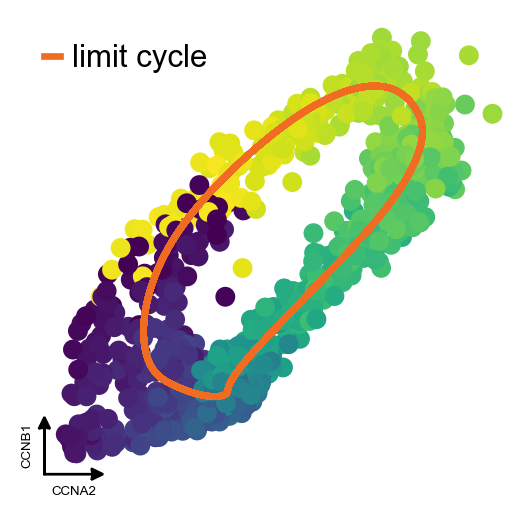

In [27]:
gene1 = 'CCNA2'
gene2 = 'CCNB1'
index1 = genes.index(gene1)
index2 = genes.index(gene2)
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(xx[index1, 5000:], xx[index2, 5000:], linewidth=3.0, color='#f16c23', label='limit cycle')
ax.scatter(np_data[:, index1], np_data[:, index2], c=th, cmap=cm.viridis, s=80, alpha=1, edgecolors='none')
arrowed_spines(ax, columns=[gene1,gene2])
ax.legend(loc='best', fontsize=14, frameon=False)
plt.savefig(f"figures/{gene1}_{gene2}_cycle.svg", bbox_inches='tight', transparent=True)
plt.show()

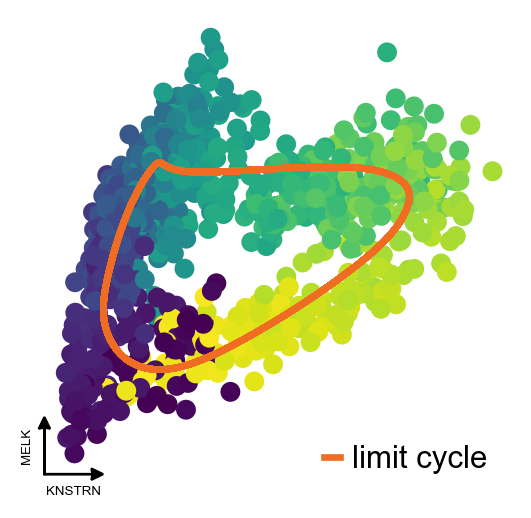

In [28]:
gene1 = 'KNSTRN'
gene2 = 'MELK'
index1 = genes.index(gene1)
index2 = genes.index(gene2)
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(xx[index1, 5000:], xx[index2, 5000:], linewidth=3.0, color='#f16c23', label='limit cycle')
ax.scatter(np_data[:, index1], np_data[:, index2], c=th, cmap=cm.viridis, s=80, alpha=1, edgecolors='none')
arrowed_spines(ax, columns=[gene1,gene2])
ax.legend(loc='best', fontsize=14, frameon=False)
plt.savefig(f"figures/{gene1}_{gene2}_cycle.svg", bbox_inches='tight', transparent=True)
plt.show()

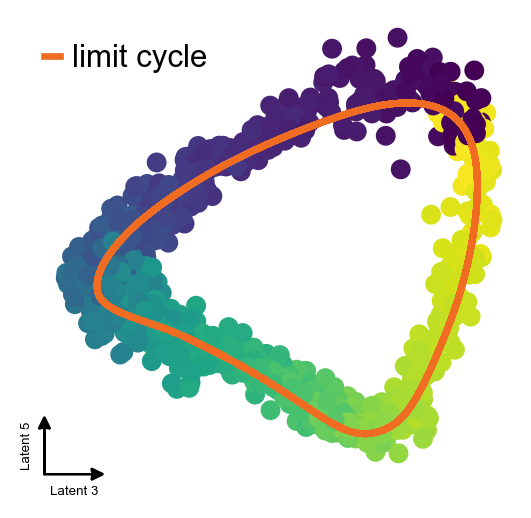

In [29]:
## 绘制latent space轨迹
index1 = 2
index2 = 4
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(latent_t[index1, 5000:], latent_t[index2, 5000:], linewidth=3.0, color='#f16c23', label='limit cycle')
ax.scatter(latent_z[:, index1], latent_z[:, index2], c=th, cmap=cm.viridis, s=80, alpha=1, edgecolors='none')
arrowed_spines(ax, columns=['Latent 3','Latent 5'])
ax.legend(loc='best', fontsize=14, frameon=False)
plt.savefig('figures/limit_cycle_latent.svg', bbox_inches='tight', transparent=True)
plt.show()

Text(0.5, 1.0, 'latent_rep')

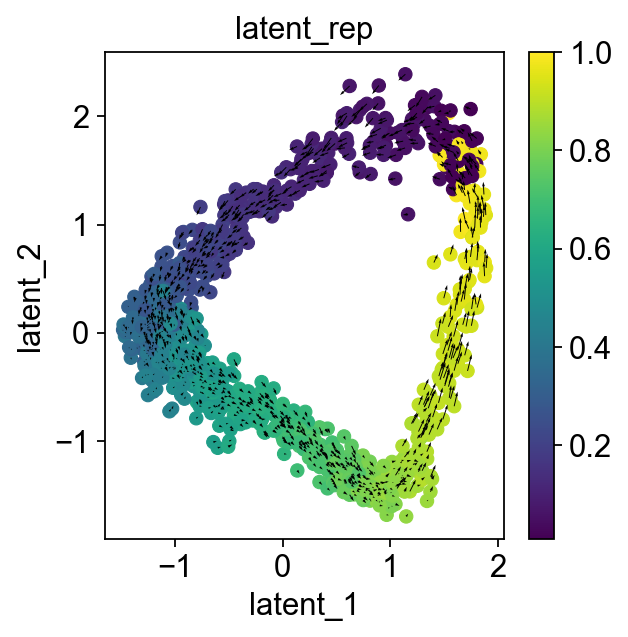

In [30]:
plt.scatter(latent_z[:, index1], latent_z[:, index2],c=th,cmap=cm.viridis)
plt.quiver(latent_z[:, index1], latent_z[:, index2], velocity[:, index1], velocity[:, index2],scale=80, scale_units='xy')
plt.colorbar(mapper, ax=plt.gca())
plt.xlabel("latent_1")
plt.ylabel("latent_2")
plt.title("latent_rep")
# plt.savefig('latent.png', dpi=300)

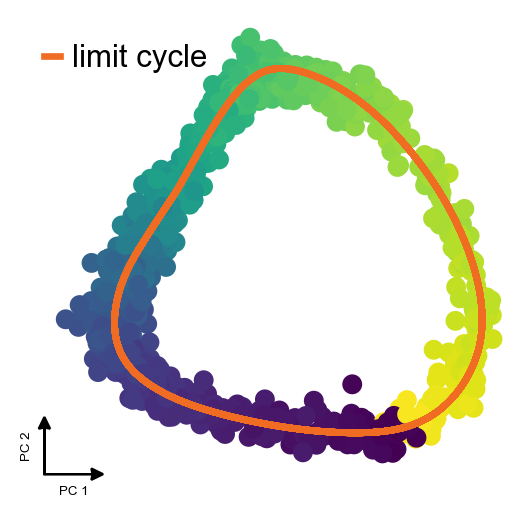

In [31]:
latent_t_pca = ((latent_t.T - np.mean(latent_z, axis=0)) @ V).T
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(latent_t_pca[0, 5000:], latent_t_pca[1, 5000:], linewidth=3.0, color='#f16c23', label='limit cycle')
ax.scatter(latent_z_pca[:, 0], latent_z_pca[:, 1], c=th, cmap=cm.viridis, s=80, alpha=1, edgecolors='none')

arrowed_spines(ax, columns='PC')
ax.legend(loc='best', fontsize=14, frameon=False)
plt.savefig('figures/limit_cycle_PC.svg', bbox_inches='tight', transparent=True)
plt.show()

Text(0.5, 1.0, 'velocity_nODE')

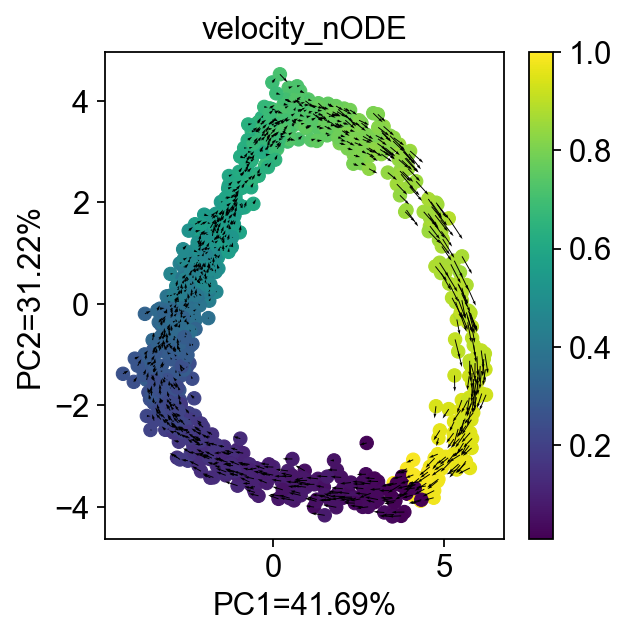

In [32]:
plt.scatter(latent_z_pca[:, 0], latent_z_pca[:, 1],c=th,cmap=cm.viridis)
plt.quiver(latent_z_pca[:, 0], latent_z_pca[:, 1], v_pca[:, 0], v_pca[:, 1],scale=60, scale_units='xy')
plt.colorbar(mapper, ax=plt.gca())
plt.xlabel(f'PC1={ratio[0] * 100:.2f}%')
plt.ylabel(f'PC2={ratio[1] * 100:.2f}%')
plt.title('velocity_nODE')
# plt.savefig('latent.png', dpi=300)

In [33]:
## 创建一个adata数据
latent_adata = ad.AnnData(latent_z, 
                          obsm={'X_z': latent_z},
                          layers = {'spliced': latent_z,
                                   'spliced_velocity': velocity},
                          )

latent_adata.obs = adata.obs
latent_adata

AnnData object with n_obs × n_vars = 1040 × 20
    obs: 'Well_Plate', 'plate', 'phase', 'MeanGreen530', 'MeanRed585', 'fucci_time', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_genes', 'n_counts', 'original_louvain_wp', 'original_louvain', 'Green530', 'Red585', 'louvain', 'theta', 'cell_cycle_theta', 'cell_cycle_phase', 'pseudotime'
    obsm: 'X_z'
    layers: 'spliced', 'spliced_velocity'

In [34]:
latent_adata.obsm['X_pca'] = latent_z_pca
latent_adata.obsm['velocity_pca'] = v_pca
latent_adata.obsm['X_2dim'] = latent_z[:,[2,4]]
latent_adata.obsm['velocity_2dim'] = velocity[:,[2,4]]
latent_adata.obsm['X_umap'] = adata.obsm['X_umap']
latent_adata.uns["velocity_params"] = {'embeddings':['pca','2dim']}

saving figure to file figures/streamplot_latent_PC.svg


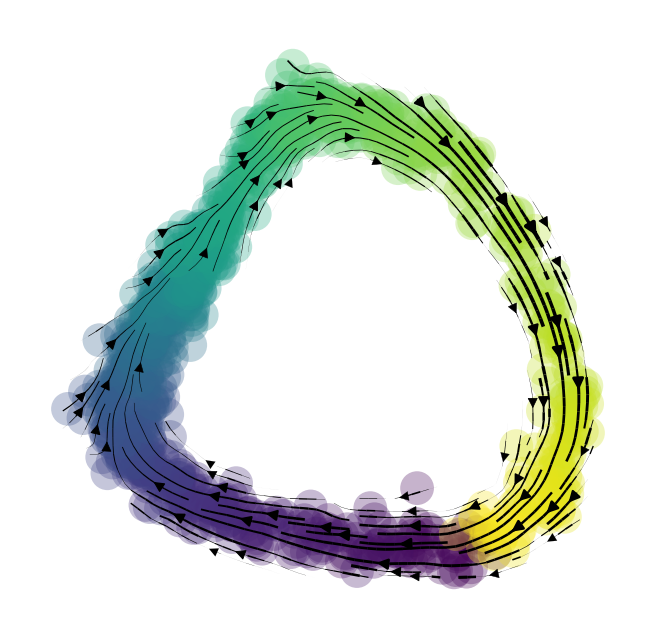

In [35]:
scv.pl.velocity_embedding_stream(
    latent_adata, 
    density=2, smooth=0.5, min_mass=1,
    basis='pca', 
    color='pseudotime', 
    title="",
    fontsize=14,
    color_map='viridis',
    colorbar=False,
    figsize=(5,5),add_margin=0.1,
    save='figures/streamplot_latent_PC.svg'
)

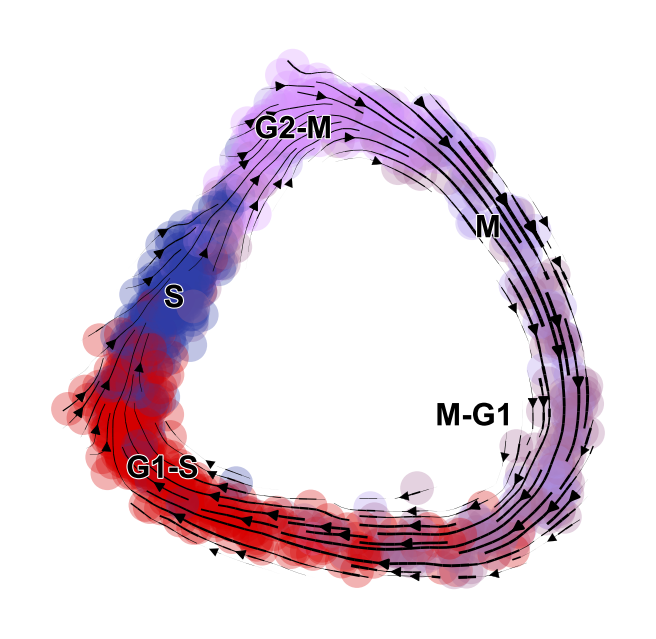

In [36]:
scv.pl.velocity_embedding_stream(
    latent_adata, 
    density=2, smooth=0.5, min_mass=1,
    basis='pca', 
    color='cell_cycle_phase', 
    title="",
    fontsize=14,
    palette={'G1-S': '#d70000',
                     'S': '#2f3ea8',
                     'G2-M': '#da96ff',
                     'M': '#ad94ec',
                     'M-G1': '#a76b9a',},
    colorbar=False,
    figsize=(5,5),add_margin=0.1,
)

saving figure to file figures/streamplot_latent.svg


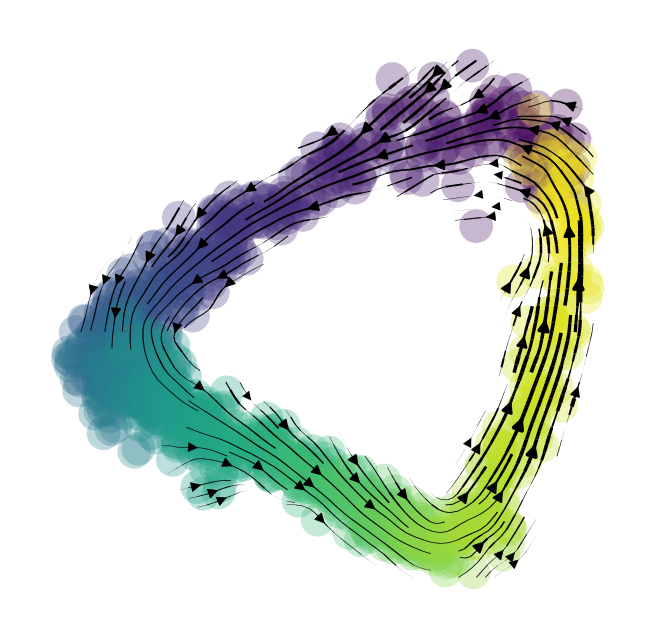

In [37]:
scv.pl.velocity_embedding_stream(
    latent_adata,
    density=2, smooth=0.5, min_mass=1,
    basis='2dim', 
    color='pseudotime', 
    title="",
    fontsize=14,
    color_map='viridis',
    colorbar=False,
    figsize=(5,5),add_margin=0.1,
    save='figures/streamplot_latent.svg'
)

computing neighbors
    finished (0:00:03) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/22 cores)


  0%|          | 0/1040 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'spliced_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'spliced_velocity_umap', embedded velocity vectors (adata.obsm)


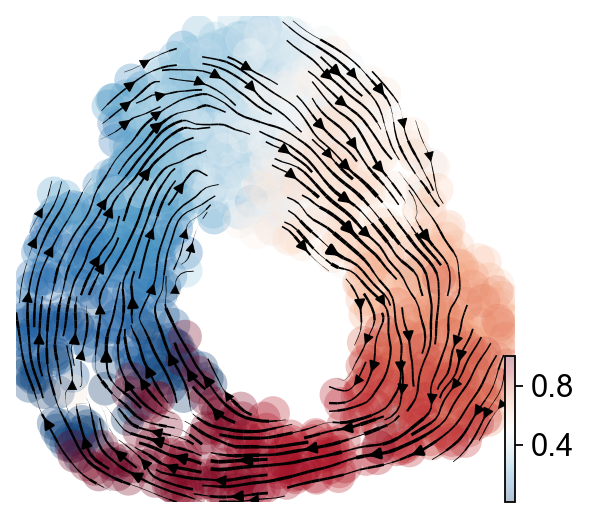

In [38]:
scv.pp.neighbors(latent_adata, n_neighbors=30, method='sklearn')

scv.tl.velocity_graph(latent_adata, vkey='spliced_velocity', xkey='spliced')
scv.tl.velocity_embedding(latent_adata, vkey='spliced_velocity', basis='umap')
scv.pl.velocity_embedding_stream(latent_adata,basis='umap',vkey='spliced_velocity', color='pseudotime',title="",
                                 # save='./figures/3.png'
                                )

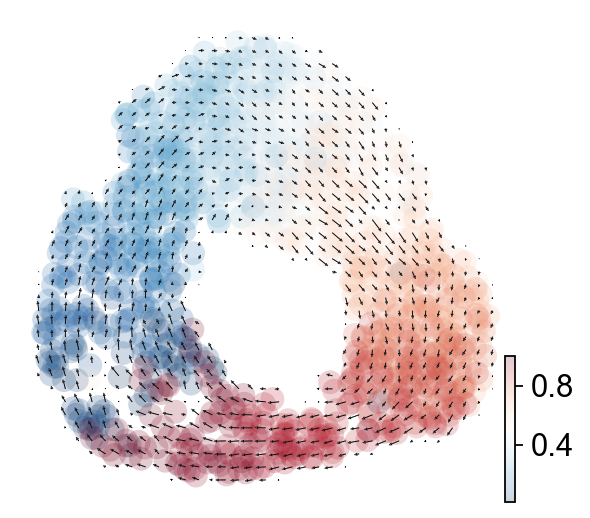

In [39]:
scv.pl.velocity_embedding_grid(latent_adata,basis='umap',vkey='spliced_velocity', color='pseudotime',title="",
                              scale=0.5,density=0.7,
                               # save='./figures/4.png'
                              )